# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: Singe IC extraction with squared Wasserstein Distance - Continous - Student-t

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from wasserstein_ica import WassersteinICA

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Define a consistent Thesis Theme
def set_thesis_theme():
    # Academic, colorblind-friendly palette
    # Blue, Orange, Green, Red, Purple, Brown
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    
    mpl.rcParams.update({
        # Figure and Layout
        'figure.figsize': (8, 5),
        'figure.dpi': 300,            # High resolution for print
        'axes.prop_cycle': mpl.cycler(color=thesis_colors),
        
        # Grid lines (light and unobtrusive)
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,       # Grid goes behind data
        
        # Spines (remove top and right borders for a cleaner look)
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Fonts and Text
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        
        # Legends
        'legend.frameon': False,      # No box around the legend
        'legend.fontsize': 10,
        
        # Lines
        'lines.linewidth': 2.0
    })

# Run this before plotting
set_thesis_theme()

In [3]:
# Simulating Student-t sources (s1 and s2)
# df=3 has finite variance but very heavy tails.
# df=30 is almost Gaussian.
n = 2000 # Keep sample size reasonable
np.random.seed(42)

# Student-t distribution with 3 degrees of freedom
# We must normalize them manually to roughly unit variance 
# (though whiten() does this later, it helps to start close)
S1 = np.random.standard_t(df=4, size=n)
S2 = np.random.standard_t(df=4, size=n)

# Stack sources
S = np.vstack([S1, S2])

In [4]:
# generating invertible mixing matrix A
#A = np.array([[1, 0.5], [0.4, 1]])

"""
A = np.array([
    [2.0,  1.0],  # Dominant axis (Mixes S1 and S2)
    [0.2, -0.4]   # Minor axis (Mixes S1 and S2 differently)
])
"""

A = np.array([
    [2.0,  0.0],  # Dominant axis (Mixes S1 and S2)
    [0.0, 0.5]   # Minor axis (Mixes S1 and S2 differently)
])

# Mixed signals X
X = A @ S

# Converting to pytorch tensors
S_torch = torch.tensor(S, dtype=torch.float32)
X_torch = torch.tensor(X, dtype=torch.float32)

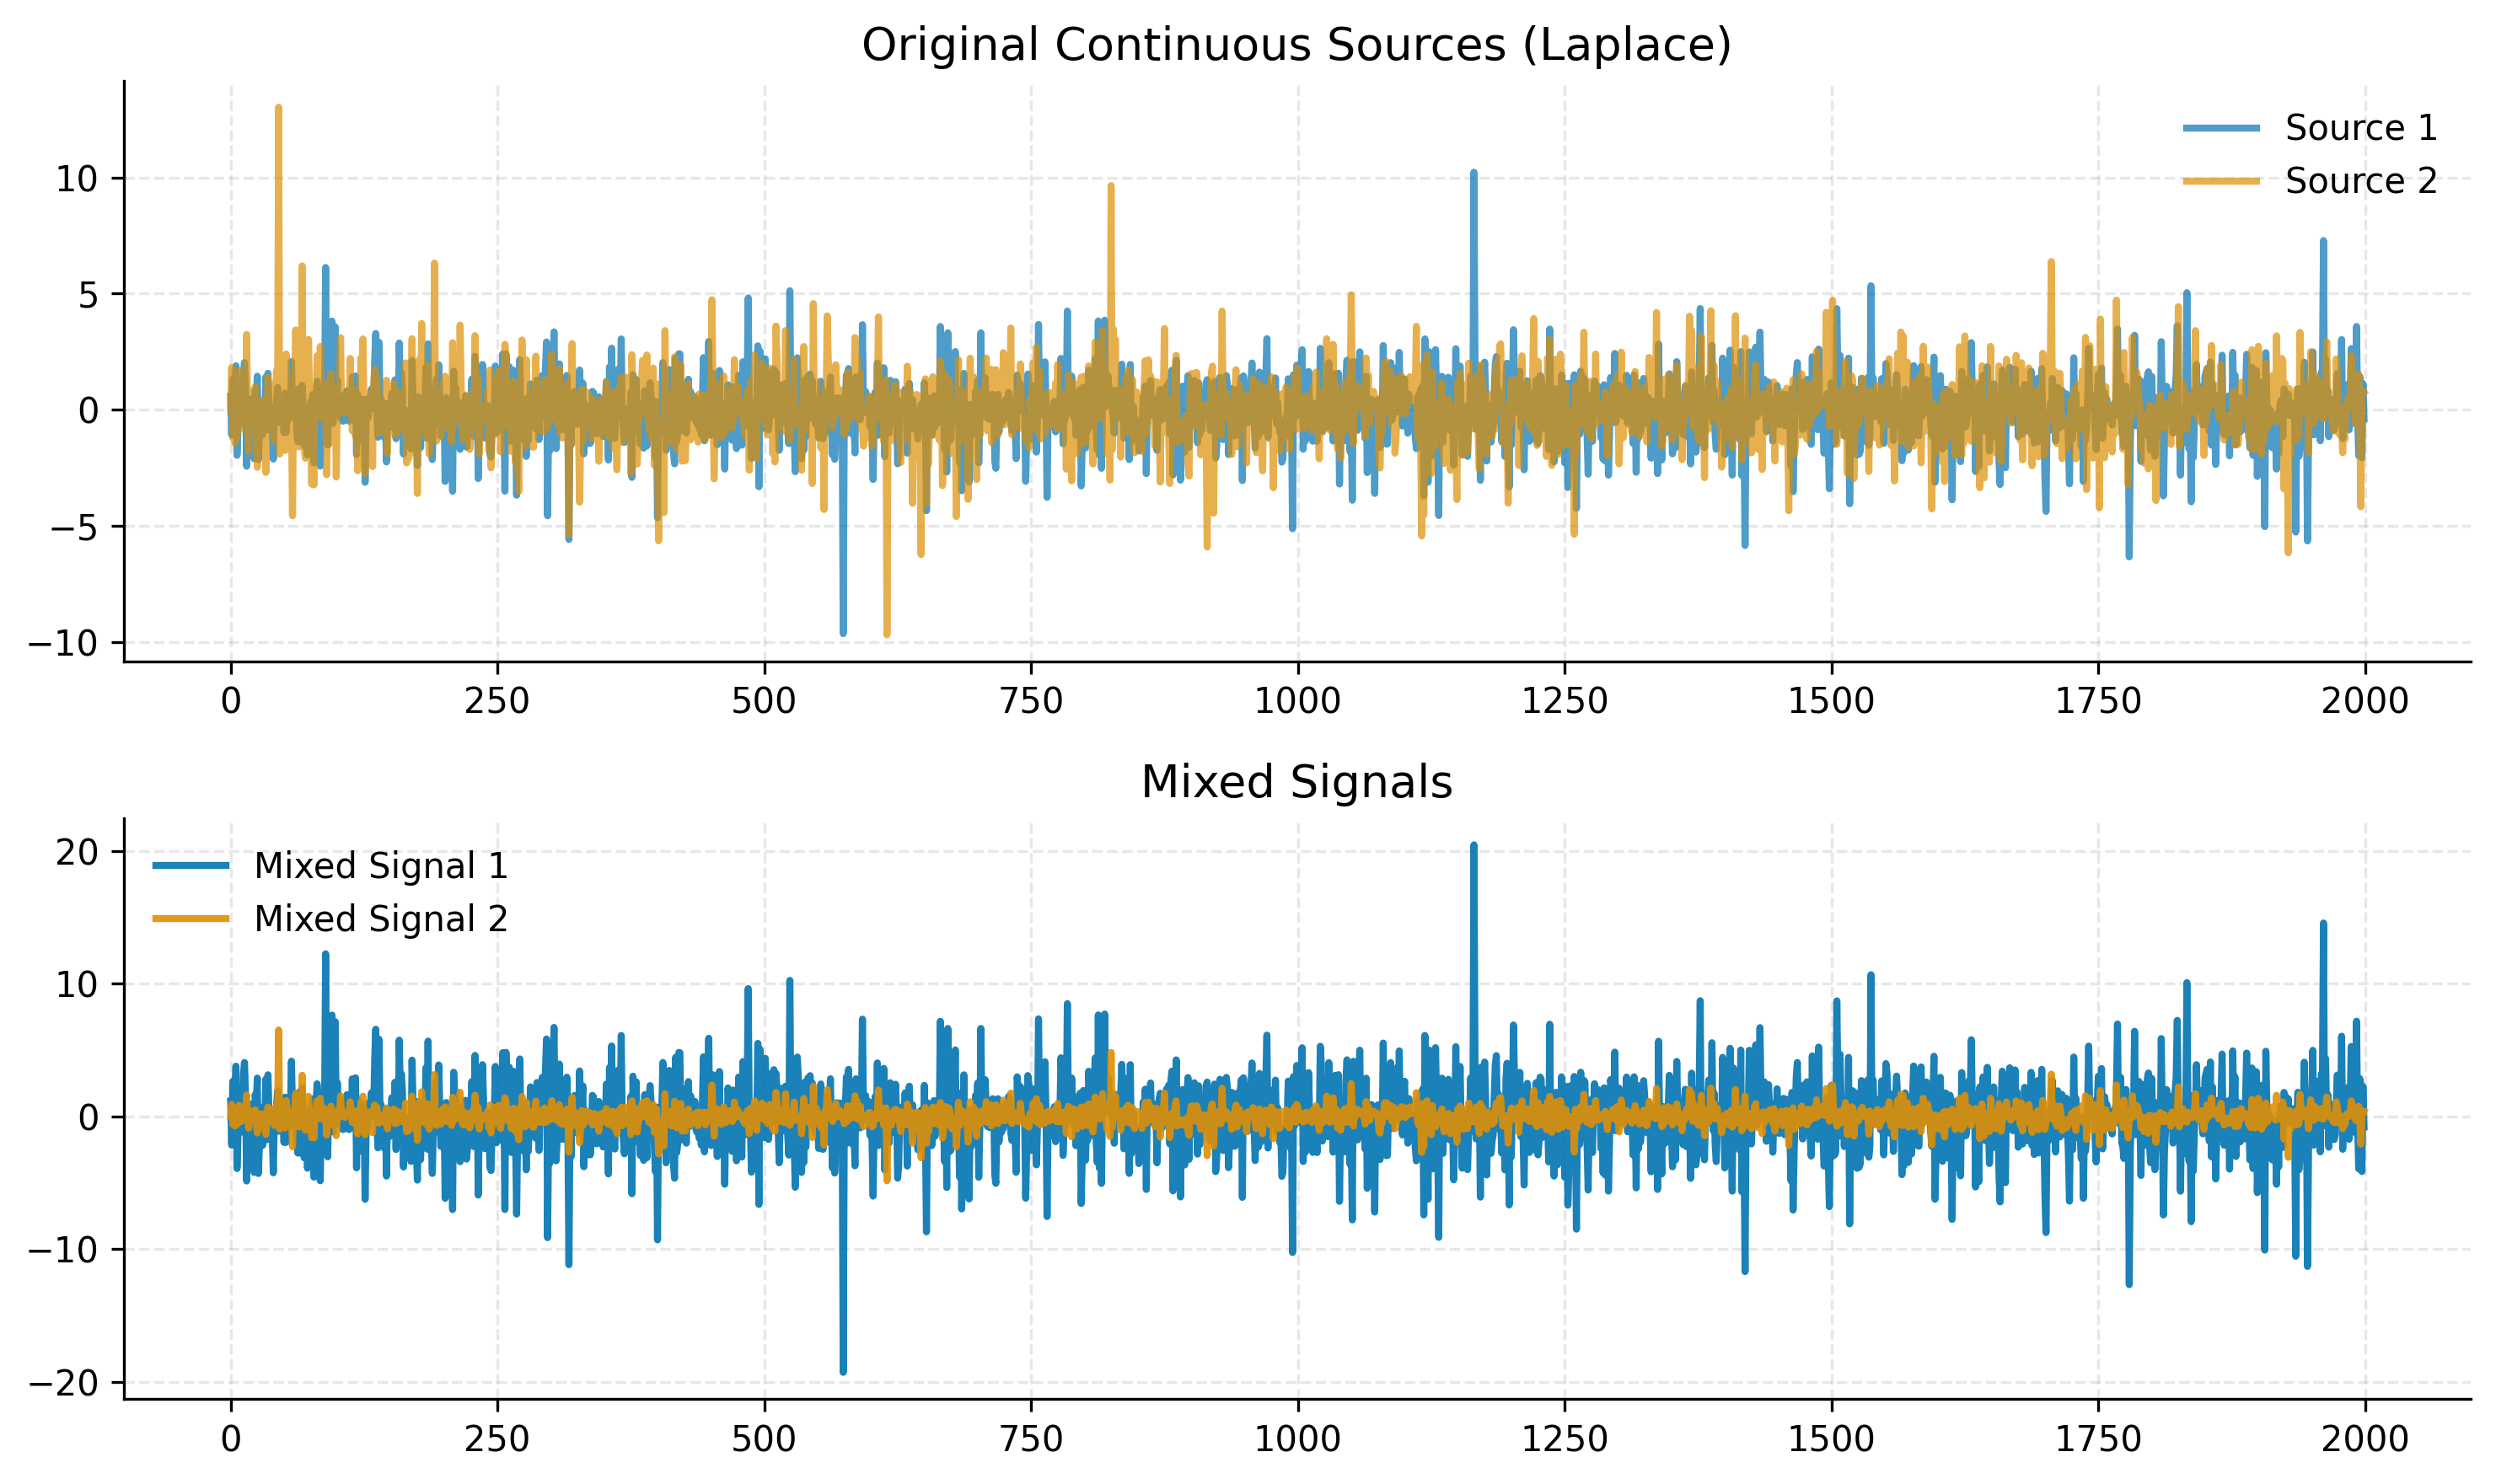

In [5]:
# Plotting sources and mixed signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.title("Original Continuous Sources (Laplace)")
plt.plot(S1, label='Source 1', alpha=0.7)
plt.plot(S2, label='Source 2', alpha=0.7)
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Mixed Signals")
plt.plot(X[0, :], label='Mixed Signal 1', alpha=0.9)
plt.plot(X[1, :], label='Mixed Signal 2', alpha=0.9)
plt.legend()

plt.tight_layout()
plt.show()


In [6]:
ica = WassersteinICA(X_torch)
ica.whiten()

cov_white = torch.matmul(ica.X_white, ica.X_white.t()) / (ica.n - 1)
print("Whitened covariance:\n", cov_white.numpy())

w1, dist1 = ica.optimize_wasserstein2(continuous=True, max_iter=100, lr=0.02)
print(f"First component Wasserstein-2 distance: {dist1:.4f}, vector: {w1.numpy()}")

# Project the whitened data onto true source and recovered components for comparison
proj_S1 = torch.mv(ica.X_white.t(), torch.tensor([1.0, 0.0], dtype=torch.float32))
proj_w1 = torch.mv(ica.X_white.t(), w1)

Whitened covariance:
 [[ 9.9998057e-01 -5.7249085e-09]
 [-5.7249085e-09  9.9999851e-01]]
First component Wasserstein-2 distance: 0.0567, vector: [ 0.9998655  -0.01640389]


In [7]:

def compare_components(a, b):
    a_norm = (a - a.mean()) / a.std()
    b_norm = (b - b.mean()) / b.std()
    corr = torch.abs(torch.corrcoef(torch.stack([a_norm, b_norm]))[0, 1]).item()
    mse = torch.mean((a_norm - b_norm) ** 2).item()
    return corr, mse

corr1, mse1 = compare_components(proj_S1, proj_w1)
print(f"Component 1: |Correlation|={corr1:.4f}, MSE={mse1:.4f}")

w1_w1 = ica.wasserstein1_distance(w1)
print(f"Wasserstein-1 distance for first component: {w1_w1.item():.4f}")

Component 1: |Correlation|=0.9999, MSE=0.0003
Wasserstein-1 distance for first component: 0.1406


In [8]:
n_grid = 2000
thetas = torch.linspace(0, np.pi, steps=n_grid, device=X_torch.device)
ws = torch.stack([torch.cos(thetas), torch.sin(thetas)], dim=1)

w1s = []
w2s = []

for w in ws:
    w_norm = w / torch.norm(w)
    w1s.append(ica.wasserstein1_distance(w_norm).item())
    w2s.append(ica.wasserstein2_distance(w_norm).item())

w1s = np.array(w1s)
w2s = np.array(w2s)

In [9]:
theta_0_idx = 0
theta_pi2_idx = (np.abs(thetas.cpu().numpy() - np.pi/2)).argmin()

print(f"W1 distance at theta=0:     {w1s[theta_0_idx]:.4f}")
print(f"W1 distance at theta=pi/2:  {w1s[theta_pi2_idx]:.4f}")
print(f"Max W1 distance:            {w1s.max():.4f} (at theta={thetas[w1s.argmax()].item():.3f} rad)")

print(f"W2 distance at theta=0:     {w2s[theta_0_idx]:.4f}")
print(f"W2 distance at theta=pi/2:  {w2s[theta_pi2_idx]:.4f}")
print(f"Max W2 distance:            {w2s.max():.4f} (at theta={thetas[w2s.argmax()].item():.3f} rad)")

W1 distance at theta=0:     0.1406
W1 distance at theta=pi/2:  0.1196
Max W1 distance:            0.1407 (at theta=3.137 rad)
W2 distance at theta=0:     0.0574
W2 distance at theta=pi/2:  0.0416
Max W2 distance:            0.0574 (at theta=0.005 rad)


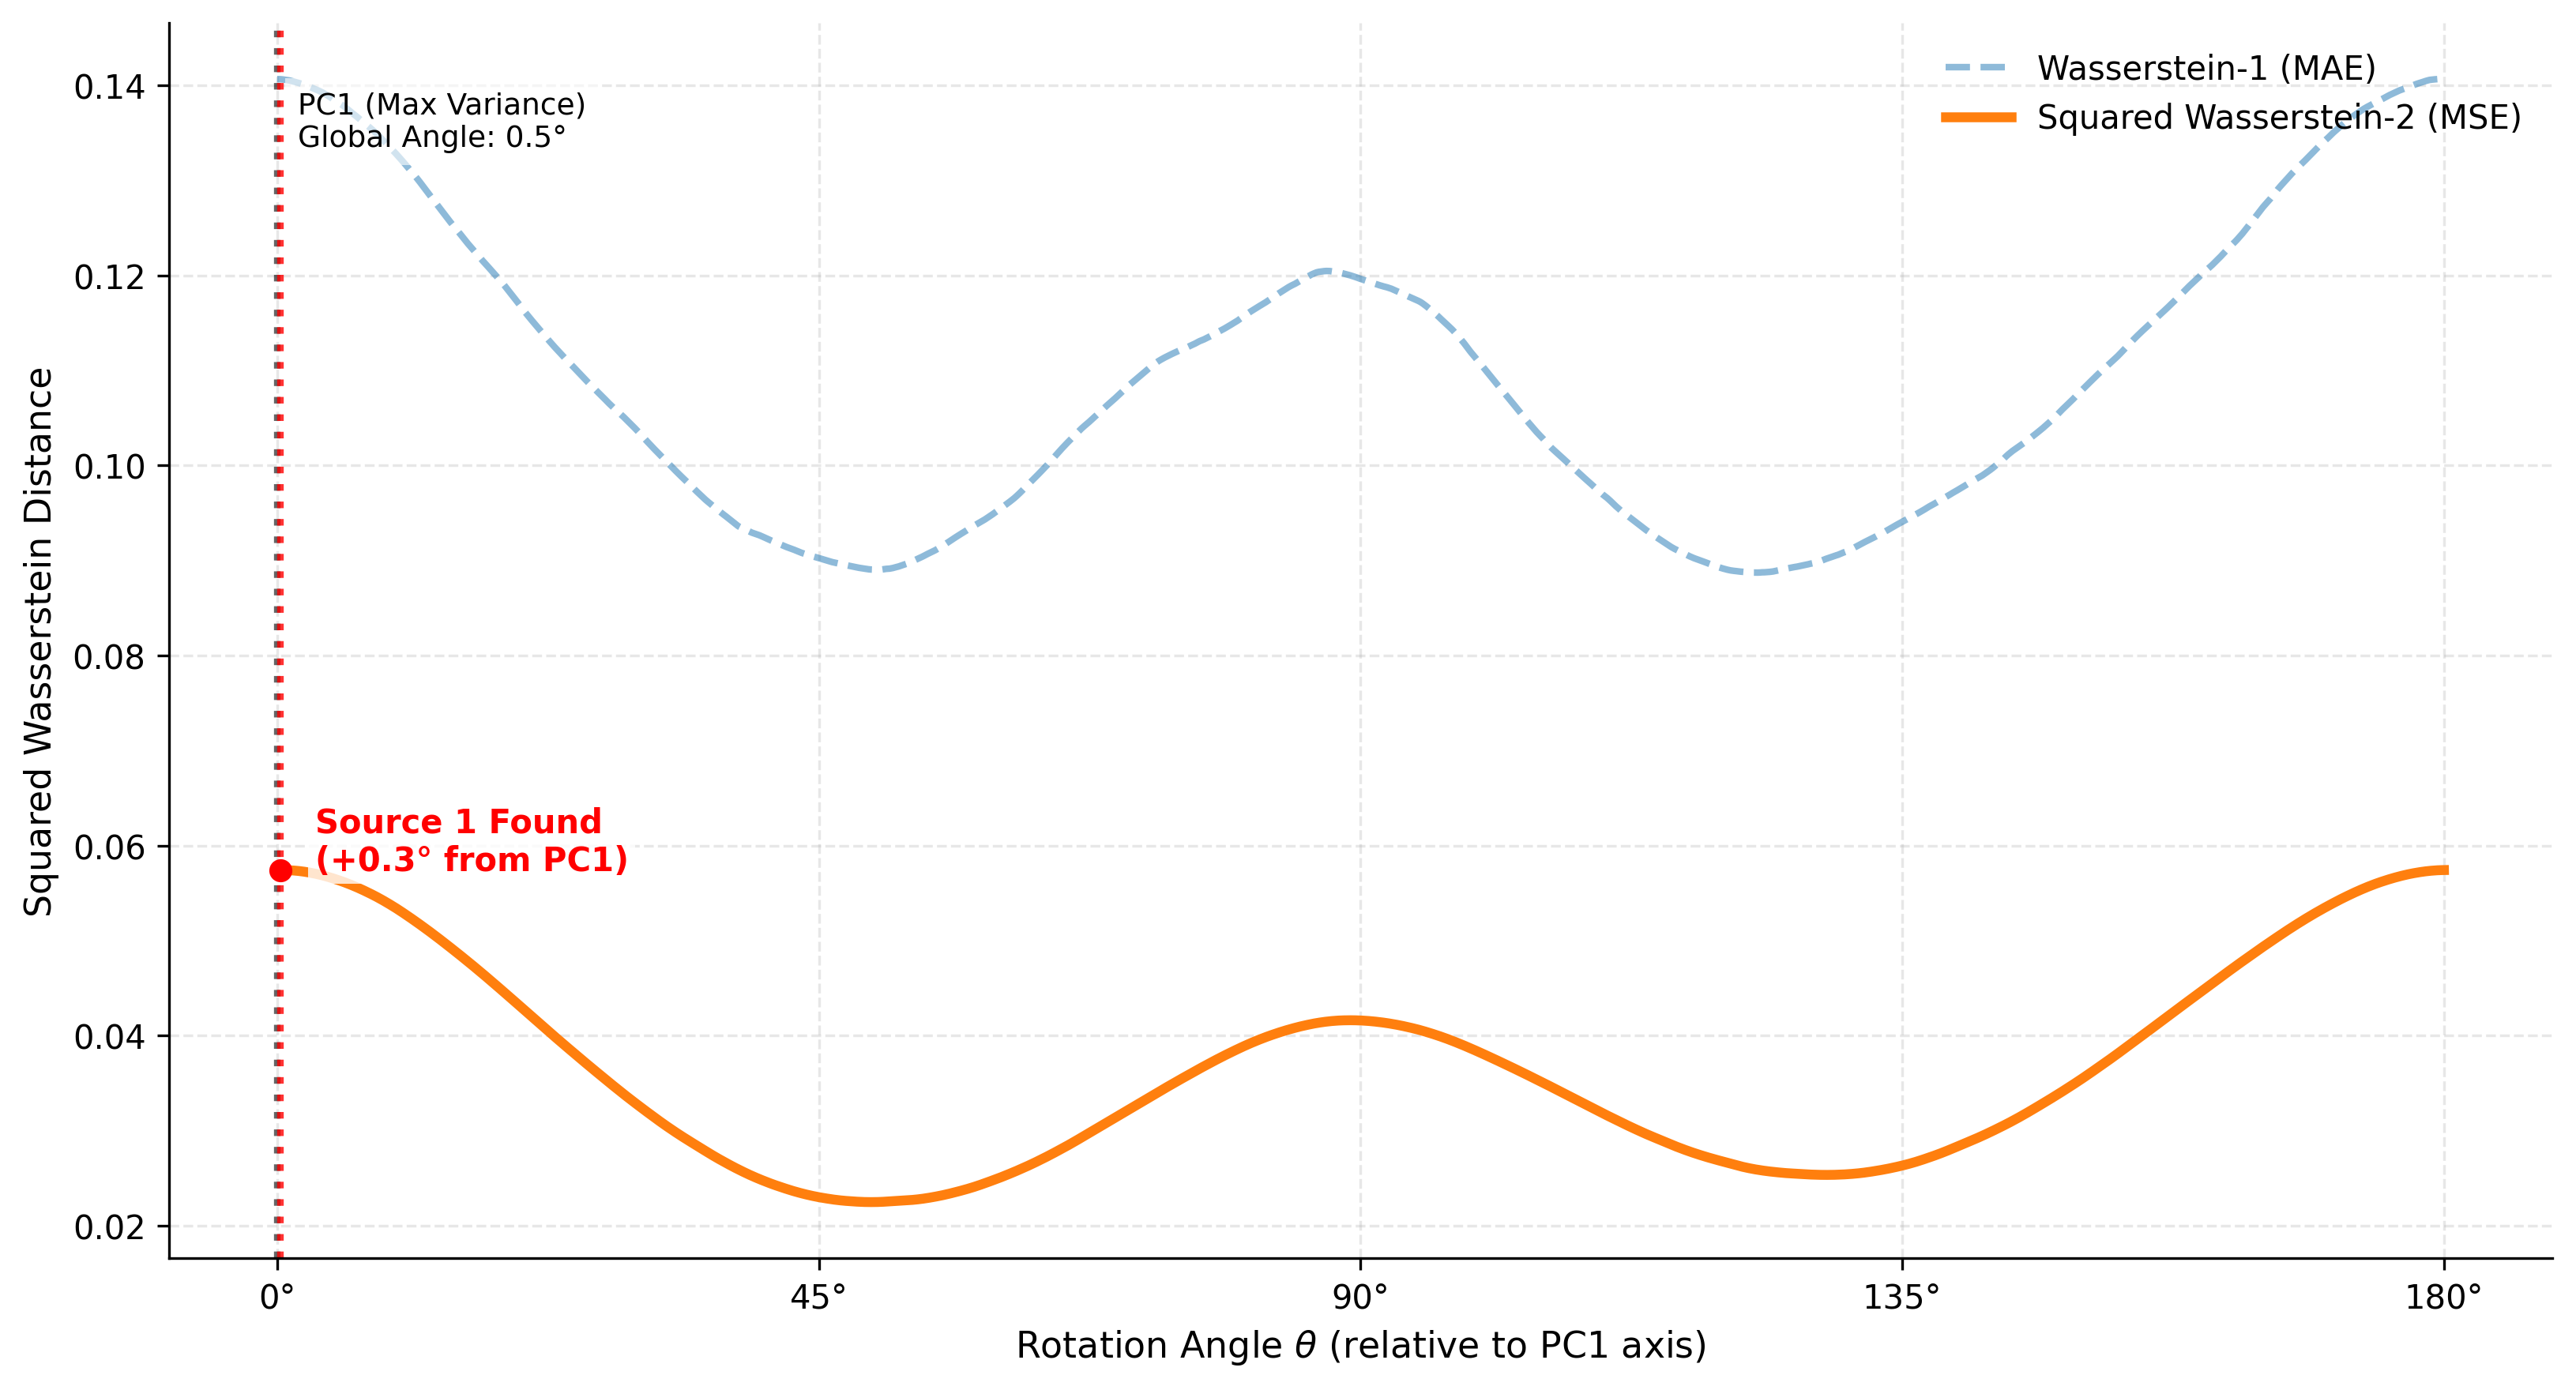

In [10]:
import matplotlib.pyplot as plt

# --- 1. Calculate the Real-World Angle of PC1 ---
# (Standard logic to find the global angle of the valley)
X_centered = X_torch - torch.mean(X_torch, dim=1, keepdim=True)
cov_X = torch.matmul(X_centered, X_centered.t()) / (n - 1)
D, E = torch.linalg.eigh(cov_X)
pc1_vector = E[:, -1] 
pc1_angle_rad = torch.atan2(pc1_vector[1], pc1_vector[0]).item()
pc1_angle_deg = np.degrees(pc1_angle_rad)

# Normalize angle to -90 to 90 range
if pc1_angle_deg > 90: pc1_angle_deg -= 180
if pc1_angle_deg < -90: pc1_angle_deg += 180

# --- 2. Find Peaks ---
# We focus on identifying the first major peak
mid_idx = len(w2s) // 2
peak1_idx = np.argmax(w2s[:mid_idx])

theta_peak1 = thetas[peak1_idx].item()
val_peak1 = w2s[peak1_idx]
deg_peak1 = np.degrees(theta_peak1)

# --- 3. Plotting ---
plt.figure(figsize=(11, 6))

# Plot Curves
plt.plot(thetas.cpu().numpy(), w1s, label="Wasserstein-1 (MAE)", color='tab:blue', alpha=0.5, ls='--')
plt.plot(thetas.cpu().numpy(), w2s, label="Squared Wasserstein-2 (MSE)", color='tab:orange', linewidth=3)

# --- ANNOTATION 1: PC1 Line (Valley) ---
plt.axvline(0, color='black', linestyle=':', alpha=0.6)
plt.text(0.03, max(w2s.max(), w1s.max()) * 0.95, 
         f"PC1 (Max Variance)\nGlobal Angle: {pc1_angle_deg:.1f}°", 
         rotation=0, color='black', fontsize=9,
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# --- ANNOTATION 2: Source 1 (The Peak) ---
# Vertical dotted line for Source 1
plt.axvline(theta_peak1, color='red', linestyle=':', linewidth=2, alpha=0.8)

# Text annotation near the line
# We place it slightly to the right of the line, near the peak height
plt.text(theta_peak1 + 0.05, val_peak1, 
         f"Source 1 Found\n(+{deg_peak1:.1f}° from PC1)", 
         color='red', fontweight='bold', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Highlight the specific peak point on the curve
plt.plot(theta_peak1, val_peak1, 'ro', markersize=6)

# Formatting
ticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
tick_labels = ["0°", "45°", "90°", "135°", "180°"]
plt.xticks(ticks, tick_labels)
plt.xlabel(r'Rotation Angle $\theta$ (relative to PC1 axis)', fontsize=11)
plt.ylabel("Squared Wasserstein Distance", fontsize=11)


plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis of ICA Optimization Landscape: Searching for Non-Gaussianity

The plot above visualizes the core objective of Independent Component Analysis (ICA): finding the rotation angle $\theta$ that maximizes the distance between the projected data and a standard Gaussian distribution $N(0,1)$.

### 1. Geometric Interpretation (The "Gap" from PCA)
The vertical dotted line at $\theta = 0^\circ$ represents the **Principal Component (PC1)** found by the whitening step.
* **PCA** aligns with the direction of maximum variance (the "widest" part of the data mixture).
* **ICA** searches for the direction of maximum **non-Gaussianity**.

As shown in the annotations, the independent Laplace sources are not aligned with PC1. The algorithm requires a rotation of **$+49.6^\circ$** and **$+140.9^\circ$** relative to the whitened frame to recover the pure sources. This confirms that while PCA removes correlations (making the data spherical), it does not separate independent signals on its own—an additional rotation based on higher-order statistics (captured here by Wasserstein distance) is required.

### 2. Comparison of Metrics: $W_1$ vs. Squared $W_2$
Both metrics successfully identify the same optimal angles, but they react to different features of the distribution:

* **Squared Wasserstein-2 ($W_2^2$, Orange Curve):** This metric (Mean Squared Error of Quantiles) is highly sensitive to **outliers and heavy tails**. Since Laplace distributions have significantly heavier tails than Gaussians, this metric provides a strong, smooth gradient pointing toward the sources. We use the squared distance to improve the convexity of the optimization landscape.
* **Wasserstein-1 ($W_1$, Blue Dashed Curve):** This metric (Mean Absolute Error) is sensitive to the **"peakedness"** of the distribution near the mean.
    * *Observation:* In this specific experiment (with sufficient sample size), $W_1$ performs surprisingly well, showing distinct peaks aligned with $W_2$. This indicates that the "sharp peak" of the Laplace source is as strong a signal as its "heavy tails."
    * *Note:* While $W_1$ aligns well visually here, $W_2^2$ is generally preferred for gradient-based optimization because it is strictly differentiable and typically smoother in lower-sample regimes.

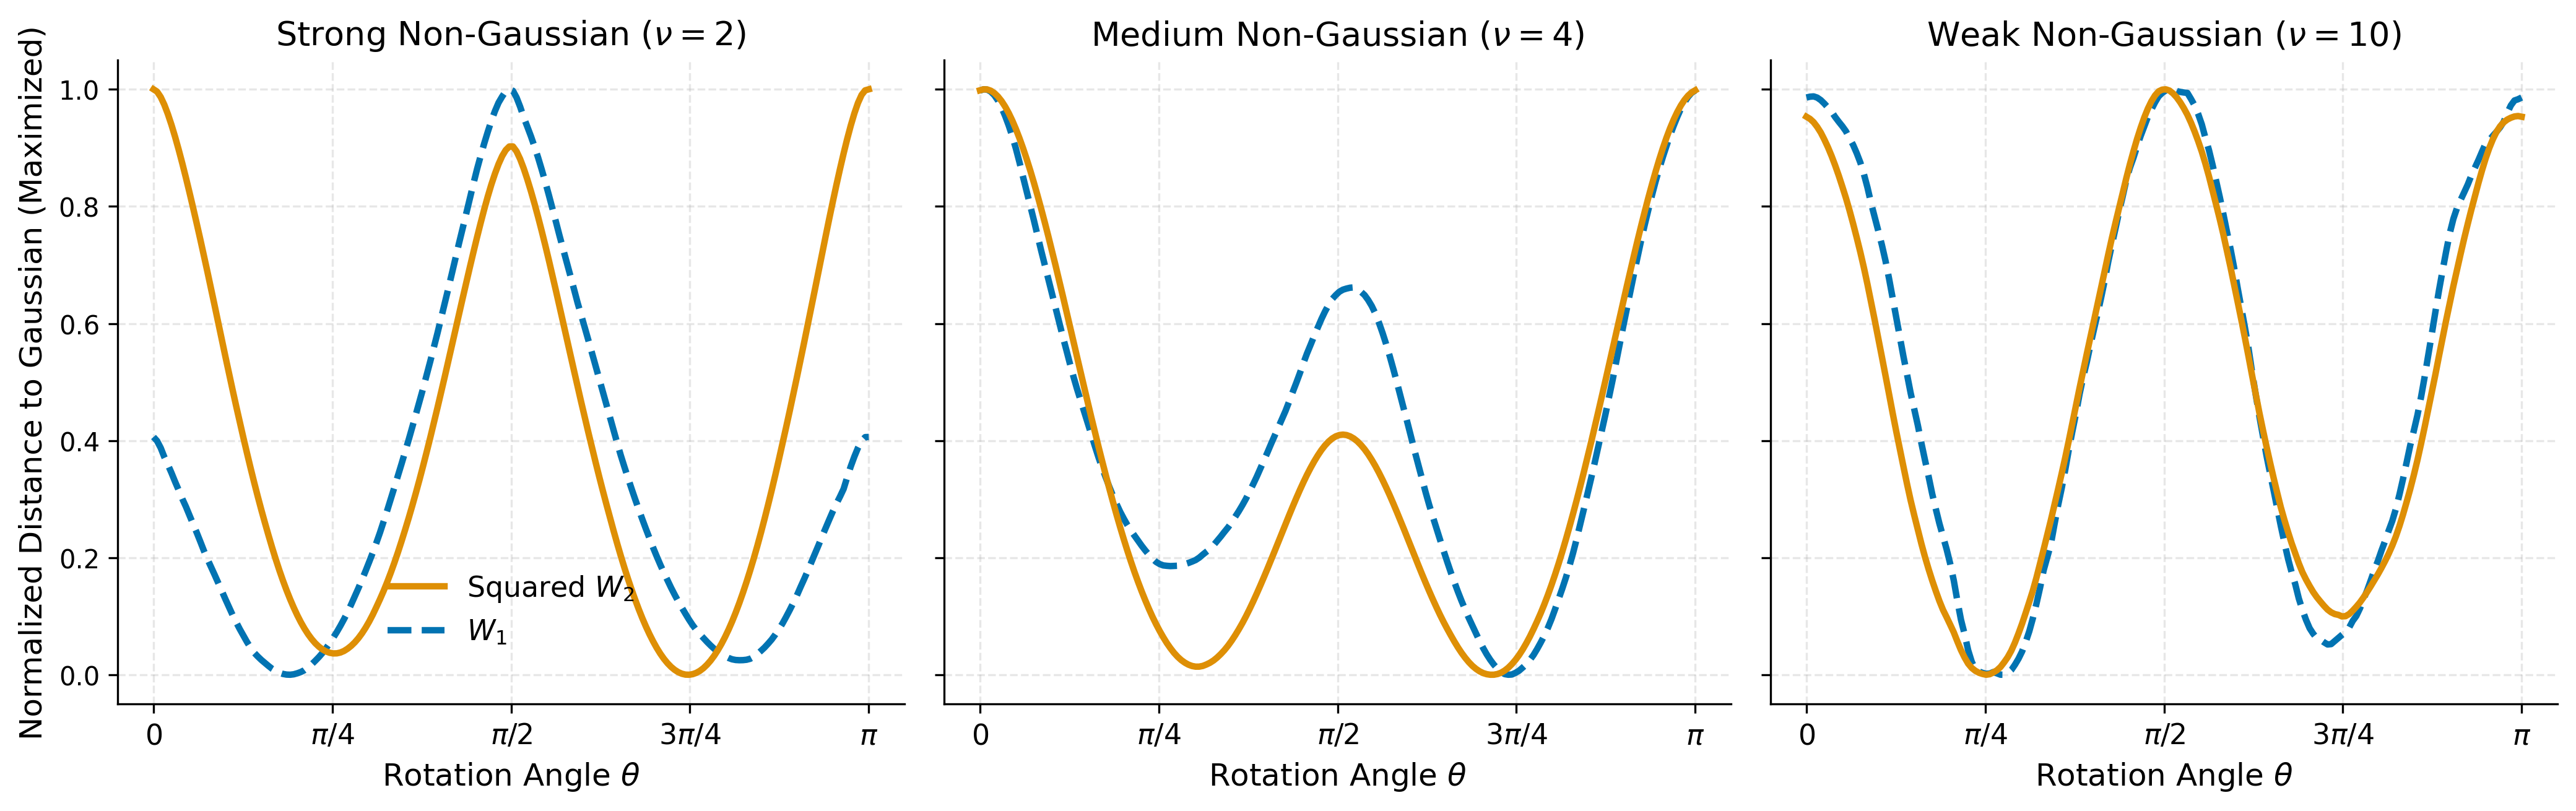

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from wasserstein_ica import WassersteinICA

# Define a consistent Thesis Theme
def set_thesis_theme():
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    mpl.rcParams.update({
        'figure.figsize': (14, 4.5),  # Kept wide for the 1x3 grid
        'figure.dpi': 300,            
        'axes.prop_cycle': mpl.cycler(color=thesis_colors),
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,       
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 12,
        'xtick.labelsize': 11,
        'ytick.labelsize': 10,
        'legend.frameon': False,      
        'legend.fontsize': 11,
        'lines.linewidth': 2.5
    })

set_thesis_theme()

dfs = [2, 4, 10]
titles = ['Strong Non-Gaussian ($\\nu=2$)', 
          'Medium Non-Gaussian ($\\nu=4$)', 
          'Weak Non-Gaussian ($\\nu=10$)']

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True)

n_samples = 5000
np.random.seed(42)

# Mixing matrix A
A = np.array([
    [2.0,  0.0],
    [0.0,  0.5]
])

for i, df in enumerate(dfs):
    # --- 1. SIMULATE DATA ---
    S1 = np.random.standard_t(df=df, size=n_samples)
    S2 = np.random.standard_t(df=df, size=n_samples)
    S = np.vstack([S1, S2])
    X = A @ S
    X_torch = torch.tensor(X, dtype=torch.float32)
    
    # --- 2. WHITEN ---
    ica = WassersteinICA(X_torch)
    ica.whiten()
    
    # --- 3. CALCULATE DISTANCES OVER ANGLES (0 to pi) ---
    # Increased steps to 200 for a smoother curve over the wider range
    theta_vals = torch.linspace(0, np.pi, steps=200, device=X_torch.device)
    ws = torch.stack([torch.cos(theta_vals), torch.sin(theta_vals)], dim=1)
    
    w1_dists = []
    w2_dists = []
    
    for w in ws:
        w_norm = w / torch.norm(w)
        w1 = ica.wasserstein1_distance(w_norm)
        w2_sq = ica.wasserstein2_distance(w_norm)
        w1_dists.append(w1.item())
        w2_dists.append(w2_sq.item())
        
    # --- 4. PLOT ---
    ax = axes[i]
    # Normalize to [0, 1] to easily compare the shapes of the peaks
    w1_norm = (np.array(w1_dists) - np.min(w1_dists)) / (np.max(w1_dists) - np.min(w1_dists))
    w2_norm = (np.array(w2_dists) - np.min(w2_dists)) / (np.max(w2_dists) - np.min(w2_dists))
    
    ax.plot(theta_vals.cpu().numpy(), w2_norm, label='Squared $W_2$', color='#DE8F05', zorder=3)
    ax.plot(theta_vals.cpu().numpy(), w1_norm, label='$W_1$', color='#0173B2', linestyle='--', zorder=2)
    
    ax.set_title(titles[i])
    ax.set_xlabel(r'Rotation Angle $\theta$')
    
    # Format X-axis with Pi ticks
    ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
    ax.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
    
    if i == 0:
        ax.set_ylabel('Normalized Distance to Gaussian (Maximized)')
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.05))

plt.tight_layout()
#plt.savefig('w1_vs_w2_landscape.png', dpi=300, bbox_inches='tight')
plt.show()

### W1 Derivative versus W2 derivative

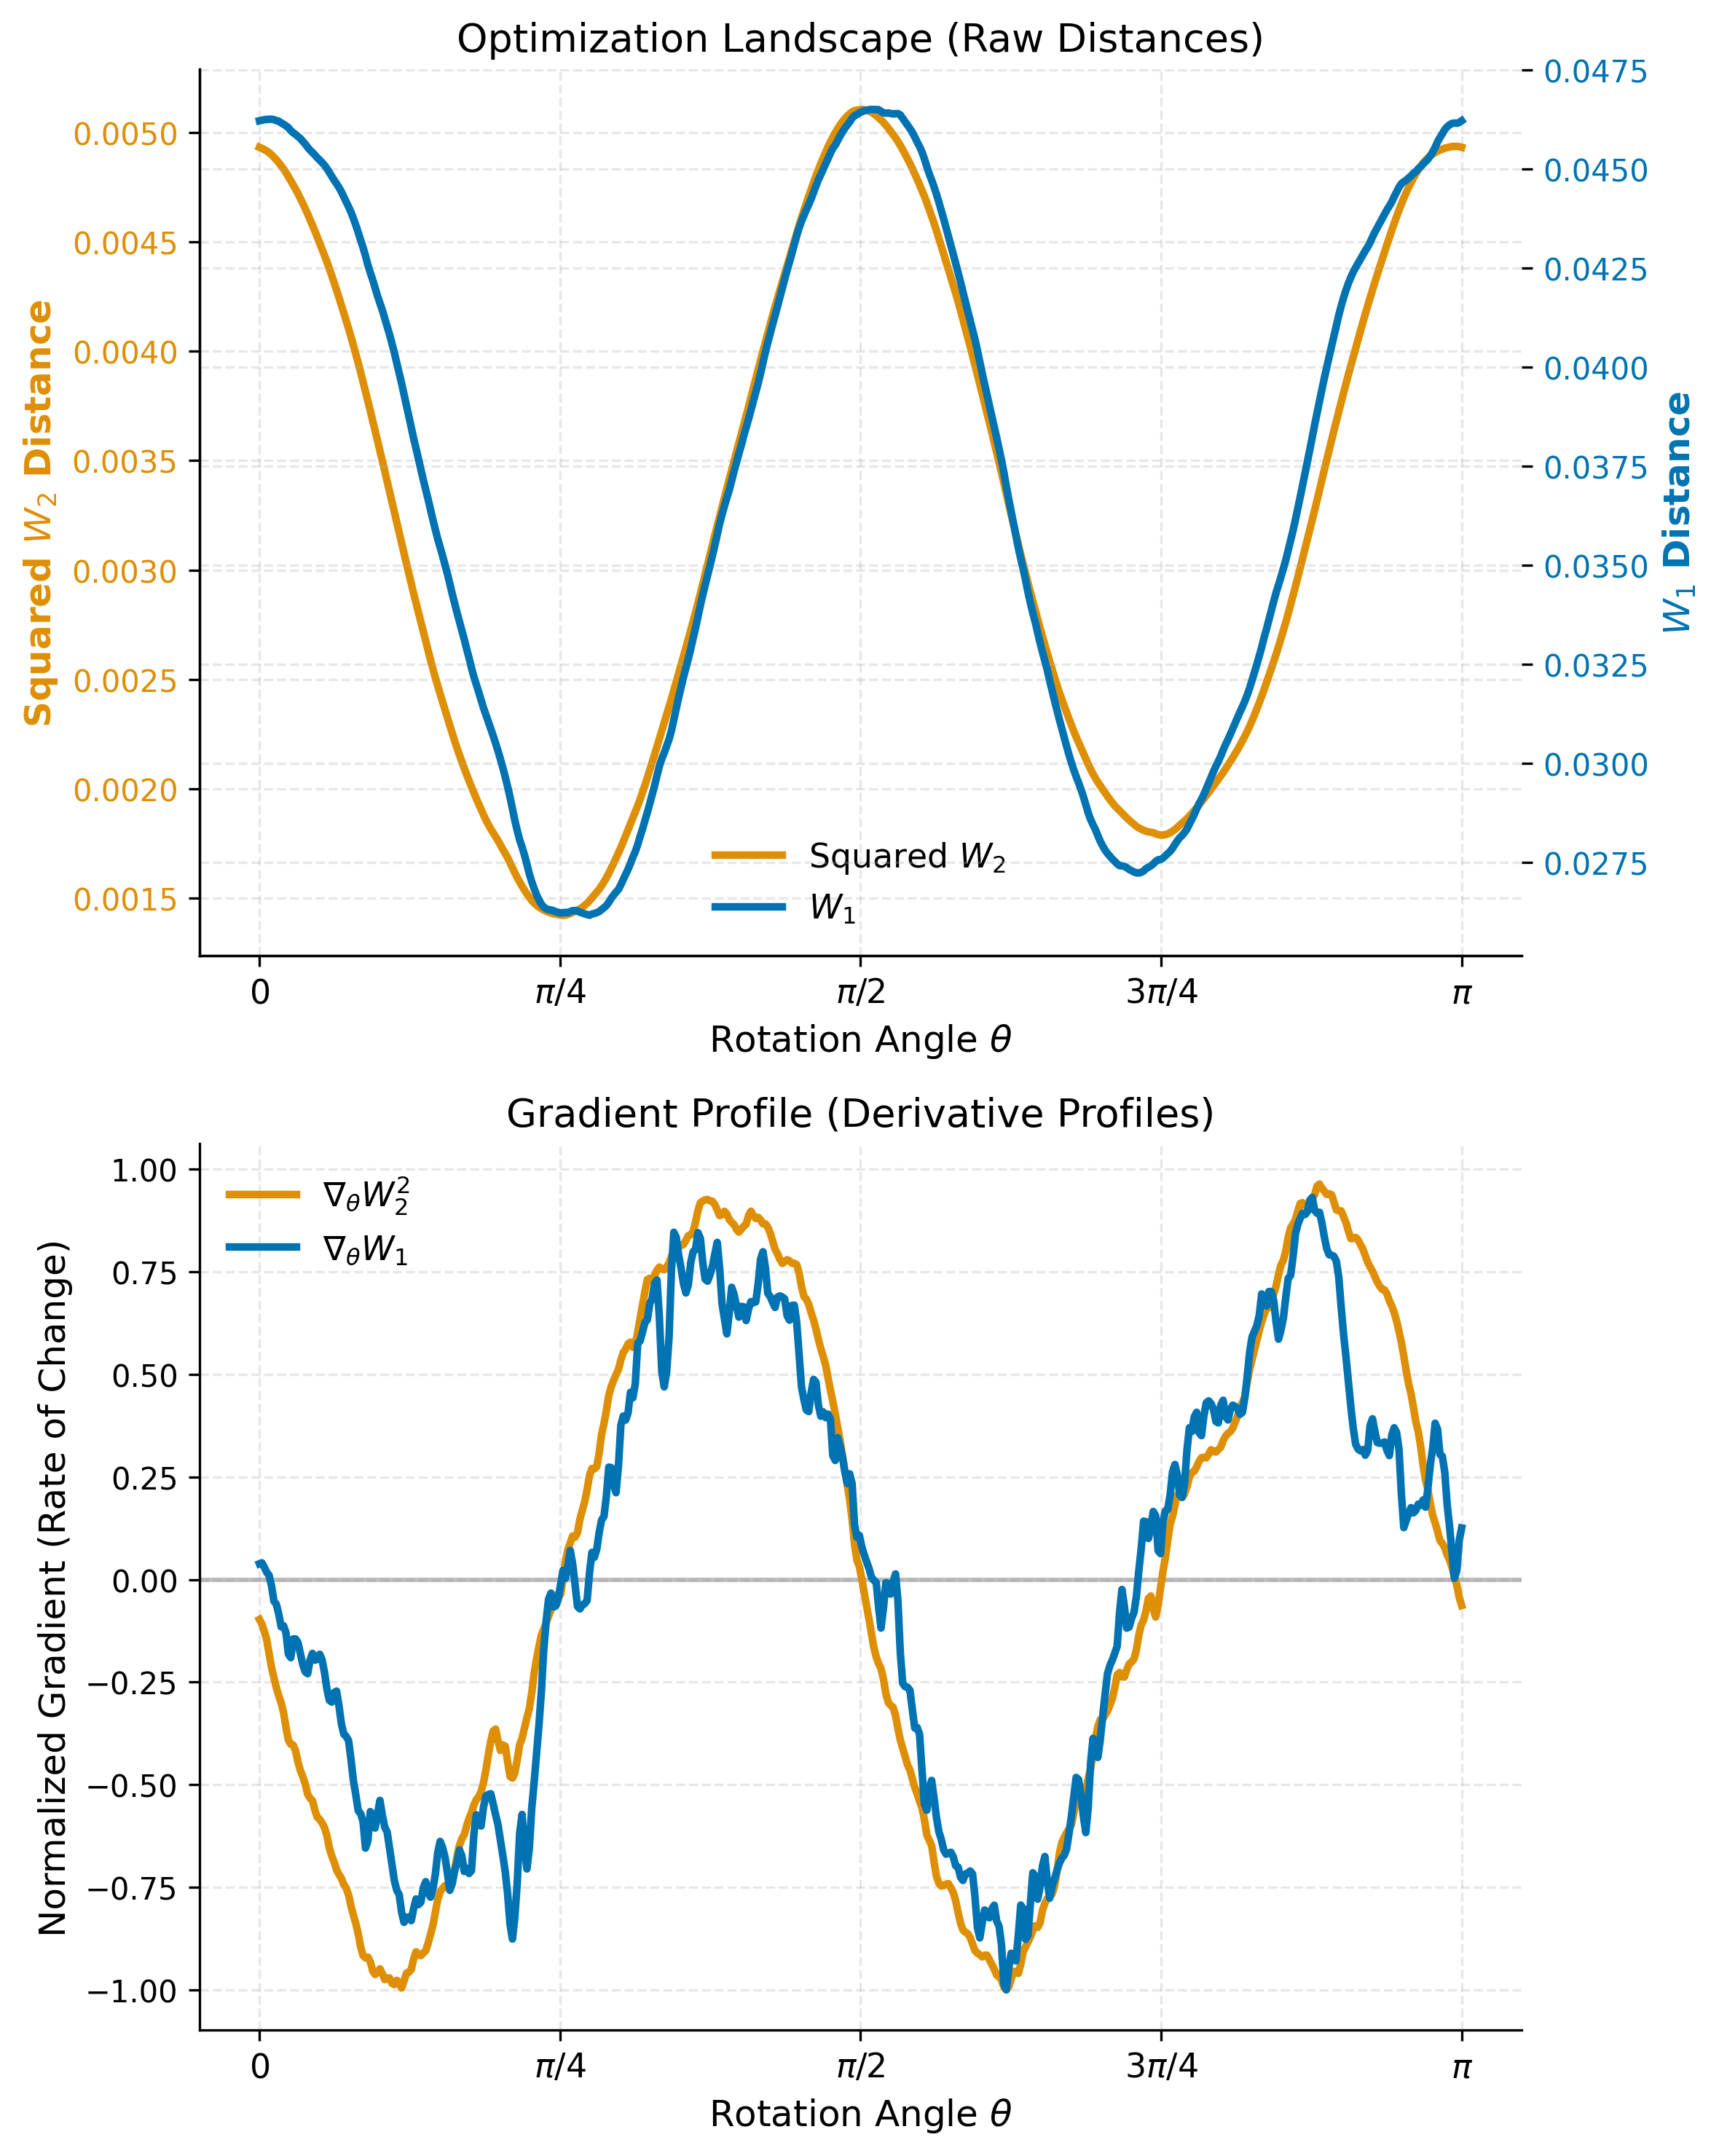

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Generate a dense grid for accurate numerical derivatives
n_grid_dense = 500
thetas_dense = torch.linspace(0, np.pi, steps=n_grid_dense, device=ica.X_white.device)
ws_dense = torch.stack([torch.cos(thetas_dense), torch.sin(thetas_dense)], dim=1)

w1_raw = []
w2_sq_raw = []

# Calculate distances across the dense grid
for w in ws_dense:
    w_norm = w / torch.norm(w)
    w1_raw.append(ica.wasserstein1_distance(w_norm).item())
    w2_sq_raw.append(ica.wasserstein2_distance(w_norm).item())

w1_raw = np.array(w1_raw)
w2_sq_raw = np.array(w2_sq_raw)
thetas_np = thetas_dense.cpu().numpy()

# 2. Calculate Numerical Gradients (Derivatives w.r.t rotation angle theta)
grad_w1 = np.gradient(w1_raw, thetas_np)
grad_w2 = np.gradient(w2_sq_raw, thetas_np)

# Normalize gradients by their max absolute value to compare their *shapes* on a [-1, 1] scale
grad_w1_norm = grad_w1 / np.max(np.abs(grad_w1))
grad_w2_norm = grad_w2 / np.max(np.abs(grad_w2))

# 3. Create the 2x1 Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# --- Panel 1: The Raw Objective Landscape ---
ax1.plot(thetas_np, w2_sq_raw, label='Squared $W_2$', color='#DE8F05', linewidth=2.5, linestyle='-')
ax1.set_xlabel(r'Rotation Angle $\theta$')
ax1.set_ylabel('Squared $W_2$ Distance', color='#DE8F05', weight='bold')
ax1.tick_params(axis='y', labelcolor='#DE8F05')
ax1.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax1.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax1.set_title('Optimization Landscape (Raw Distances)')

ax1_twin = ax1.twinx()
ax1_twin.plot(thetas_np, w1_raw, label='$W_1$', color='#0173B2', linestyle='-', linewidth=2.5)
ax1_twin.set_ylabel('$W_1$ Distance', color='#0173B2', weight='bold')
ax1_twin.tick_params(axis='y', labelcolor='#0173B2')
ax1_twin.spines['top'].set_visible(False)

# FIXED: Combine handles and labels from both axes into a single legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center', ncol=1)

# --- Panel 2: The Gradient Profile ---
ax2.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5) # The Zero line

ax2.plot(thetas_np, grad_w2_norm, label=r'$\nabla_\theta W_2^2$', color='#DE8F05', linewidth=2.5, linestyle='-')
ax2.plot(thetas_np, grad_w1_norm, label=r'$\nabla_\theta W_1$', color='#0173B2', linestyle='-', linewidth=2.5)

ax2.set_xlabel(r'Rotation Angle $\theta$')
ax2.set_ylabel('Normalized Gradient (Rate of Change)')
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax2.set_title('Gradient Profile (Derivative Profiles)')
ax2.legend(loc='upper left', ncol=1)

plt.tight_layout()
plt.savefig('w1_vs_w2_derivatives.png', dpi=300, bbox_inches='tight')
plt.show()